In [1]:
import pandas as pd

df = pd.read_csv("DataSet.csv")

print(df.shape)
print(df.head())

(9082, 3925)
   Unnamed: 0  F1  F2  F3  F4  F5  F6  F7  F8  F9  ...  F3915  F3916  F3917  \
0           1 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...      0      1      0   
1           2 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...      0      1      0   
2           3 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...      0      1      0   
3           4 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...      0      1      0   
4           5 NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...      0      1      0   

   F3918  F3919  F3920  F3921  F3922  F3923  F3924  
0      0      1      0      0      1      0      0  
1      0      1      0      1      0      0      0  
2      0      1      0      0      1      0      0  
3      0      1      0      0      1      0      0  
4      0      1      0      1      0      0      0  

[5 rows x 3925 columns]


In [2]:
print(df["F3924"].value_counts())

F3924
0    9001
1      81
Name: count, dtype: int64


In [3]:
features = [
    "F115","F321","F527","F531","F670",
    "F1692","F2082","F2122","F2582",
    "F2678","F2737","F2956","F3043",
    "F3836","F3887","F3889","F3891","F3894"
]
## X= feature_column ; Y = target_column

X = df[features]

Y = df["F3924"]

In [4]:
X= X.fillna(0)

for col in X.columns:

    if X[col].dtype == "object":

        X[col] = pd.factorize(X[col])[0]

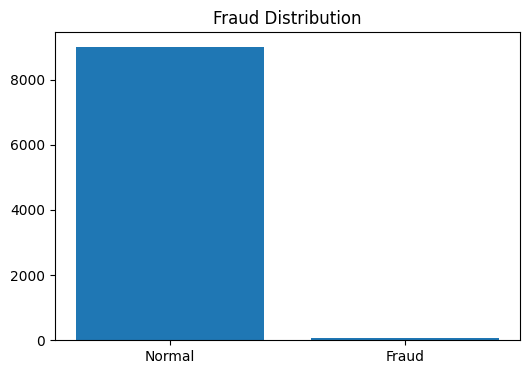

In [5]:
import matplotlib.pyplot as plt

fraud_count = Y.value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    ["Normal","Fraud"],
    fraud_count.values
)

plt.title("Fraud Distribution")

plt.savefig("fraud_distribution.png")

plt.show()

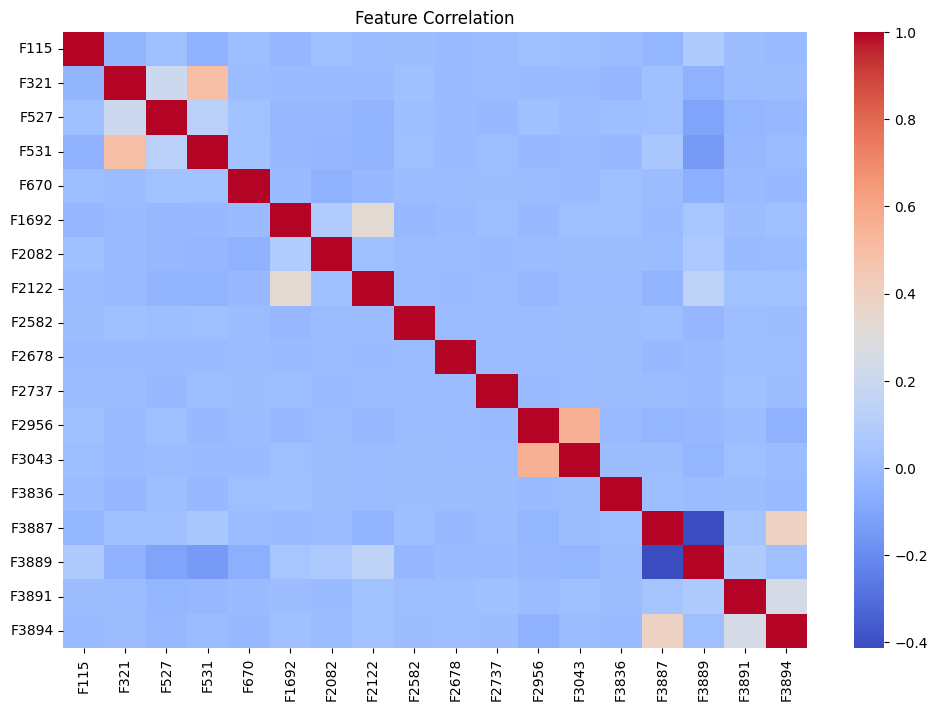

In [7]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    X.corr(),
    cmap="coolwarm"
)
## Blue = negative correlation; Red = Negative correlation ; White = neutral
plt.title("Feature Correlation")

plt.savefig("correlation_heatmap.png")

plt.show()

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(

    X,
    Y,

    test_size=0.2,

    random_state=42,

    stratify=Y
)

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
from sklearn.metrics import accuracy_score

models = {
    "Random Forest":rf,
    "Decision Tree":dt,
    "Logistic Regression":lr
}

results = []

for name, model in models.items():

    pred = model.predict(X_test)

    acc = accuracy_score(
        Y_test,
        pred
    )

    results.append(
        [name,acc]
    )

result_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy"]
)

print(result_df)

                 Model  Accuracy
0        Random Forest  0.991194
1        Decision Tree  0.982939
2  Logistic Regression  0.989543


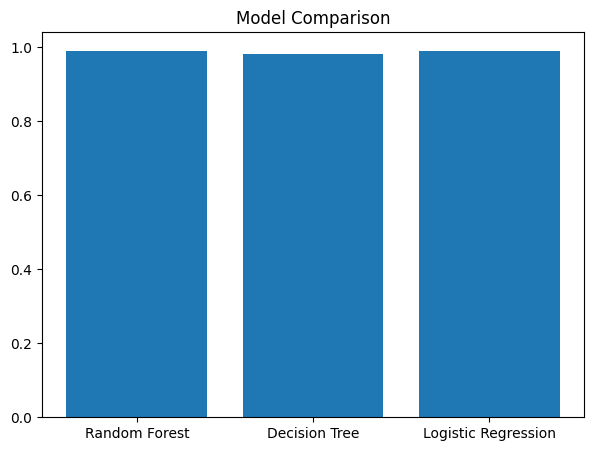

In [14]:
plt.figure(figsize=(7,5))

plt.bar(
    result_df["Model"],
    result_df["Accuracy"]
)

plt.title("Model Comparison")

plt.savefig(
    "model_comparison.png"
)

plt.show()

In [15]:
model = rf

pred = model.predict(X_test)

In [16]:
from sklearn.metrics import classification_report

print(
    classification_report(
       Y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1801
           1       0.00      0.00      0.00        16

    accuracy                           0.99      1817
   macro avg       0.50      0.50      0.50      1817
weighted avg       0.98      0.99      0.99      1817



C:\Users\Bavadarini\mlpro\env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Bavadarini\mlpro\env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Bavadarini\mlpro\env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


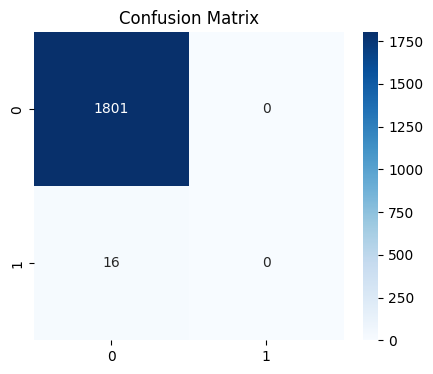

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    Y_test,
    pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.savefig(
    "confusion_matrix.png"
)

plt.show()

In [19]:
importance = pd.DataFrame({

    "Feature":features,

    "Importance":
    model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

   Feature  Importance
10   F2737    0.108082
13   F3836    0.096529
11   F2956    0.089767
14   F3887    0.081893
1     F321    0.080737
0     F115    0.074091
17   F3894    0.070264
3     F531    0.070167
8    F2582    0.067677
2     F527    0.065671
9    F2678    0.065433
16   F3891    0.032671
12   F3043    0.031860
7    F2122    0.026702
4     F670    0.016093
15   F3889    0.011795
5    F1692    0.007901
6    F2082    0.002667


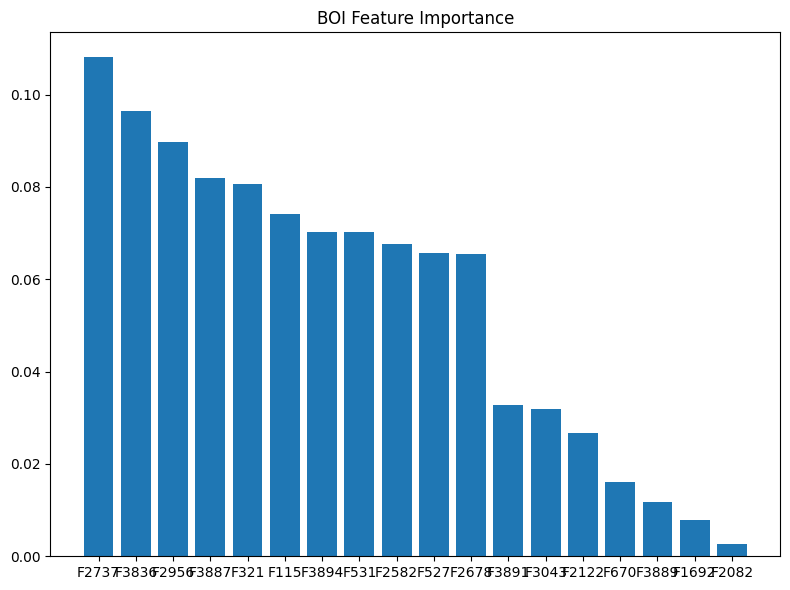

In [20]:
plt.figure(figsize=(8,6))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "BOI Feature Importance"
)

plt.tight_layout()

plt.savefig(
    "feature_importance.png"
)

plt.show()

In [21]:
risk_scores = model.predict_proba(
    X_test
)

results = X_test.copy()

results["Actual"] = Y_test.values

results["Risk Score"] = risk_scores[:,1] * 100

In [22]:
def risk_level(score):

    if score >= 80:
        return "High"

    elif score >= 50:
        return "Medium"

    else:
        return "Low"

results["Risk Level"] = results[
    "Risk Score"
].apply(risk_level)

print(
    results[
        ["Actual",
         "Risk Score",
         "Risk Level"]
    ].head(20)
)

      Actual  Risk Score Risk Level
6557       0         0.0        Low
8972       0         4.0        Low
5690       0         0.0        Low
3327       0         0.0        Low
3495       0         1.0        Low
8135       0         0.0        Low
2349       0         2.0        Low
6015       0         0.0        Low
3389       0         2.0        Low
8782       0         0.0        Low
5088       0         0.0        Low
2047       0         0.0        Low
4455       0         2.0        Low
8594       0         1.0        Low
6877       0         0.0        Low
8308       0         0.0        Low
6966       0         2.0        Low
4282       0         3.0        Low
7577       0         0.0        Low
1976       0         0.0        Low


In [23]:
high_risk = results[
    results["Risk Score"] > 80
]

print(
    high_risk[
        ["Actual",
         "Risk Score",
         "Risk Level"]
    ].head(20)
)

Empty DataFrame
Columns: [Actual, Risk Score, Risk Level]
Index: []
